# Hidden Markov Model for Human Activity Recognition
## Group Project - Formative 2

This notebook implements a Hidden Markov Model to classify human activities (Standing, Walking, Jumping, Still) using accelerometer and gyroscope data from smartphone sensors.

### Background and Motivation

Human Activity Recognition (HAR) is a foundational problem in ubiquitous computing with real-world applications in health monitoring, rehabilitation, sports science, and smart device interaction. Smartphones carry high-quality inertial measurement units (IMUs) that are always available, making them ideal passive sensors for continuous activity monitoring without requiring specialist hardware.

Our unique use case targets **automated wellness monitoring**: by recognising sedentary behaviour (Still/Standing) versus active behaviour (Walking/Jumping) from a single pocket smartphone, a health application could unobtrusively log activity levels throughout the day and flag prolonged inactivity — a risk factor for cardiovascular disease and type 2 diabetes. Hidden Markov Models are particularly well-suited here because they explicitly model the *temporal transitions* between activity states (e.g., the gradual onset of walking from standing), which threshold-based or static classifiers cannot capture.

### Project Overview
- **Activities**: Standing, Walking, Jumping, Still
- **Sensors**: Accelerometer and Gyroscope (x, y, z axes)
- **Device**: iPhone 12 Pro (all group members)
- **Sampling Rate**: 20 ms (50 Hz) — consistent across all recordings
- **Total Recordings**: 120 (30 per activity)

### Group Members

| Name | Device | Sampling Rate | Recordings Contributed |
|------|--------|--------------|----------------------|
| Elissa Twizeyimana | iPhone 12    | 50 Hz | 60 |
| Uwingabire Caline | iPhone 12 Pro | 50 Hz | 60 |

### Task Allocation

| Task | Responsible Member(s) |
|------|-----------------------|
| Data collection & labelling | Elissa Twizeyimana & Uwingabire Caline |
| Feature extraction design | Elissa Twizeyimana & Uwingabire Caline |
| HMM implementation (GaussianHMM class) | Elissa Twizeyimana & Uwingabire Caline |
| Evaluation & visualisations | Elissa Twizeyimana & Uwingabire Caline |
| Report writing | Elissa Twizeyimana & Uwingabire Caline |

## 1. Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import signal, stats
from scipy.fft import fft, fftfreq
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configure matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Configure Data Path

Choose your environment and set the appropriate data path.

In [2]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Set the path to the Data folder in your Google Drive.
# Update this to match your actual folder structure.
base_path = '/content/drive/MyDrive/Colab Notebooks/fommatives/Data'

print(f"Data path set to: {base_path}")

# Verify the data path exists and list activity folders
if os.path.exists(base_path):
    print("Data directory found.")
    activities = ['Jumping', 'Standing', 'Still', 'Walking']
    found_activities = []
    for activity in activities:
        activity_path = os.path.join(base_path, activity)
        if os.path.exists(activity_path):
            found_activities.append(activity)

    if found_activities:
        print(f"Found {len(found_activities)} activity folders: {', '.join(found_activities)}")
    else:
        print(f"Warning: No activity folders found. Expected: {', '.join(activities)}")
else:
    print(f"ERROR: Data directory not found at: {base_path}")
    print("Check your Google Drive folder structure and update base_path above.")


Mounted at /content/drive
Data path set to: /content/drive/MyDrive/Colab Notebooks/fommatives/Data
Data directory found.
Found 4 activity folders: Jumping, Standing, Still, Walking


## 3. Data Loading Functions

In [3]:
def load_sensor_data(activity_path):
    """
    Load accelerometer and gyroscope data from a specific activity recording.
    Robustly handles variable column counts and CSV formats across different
    recording sessions / app versions.
    """
    try:
        accel_raw = pd.read_csv(activity_path / 'Accelerometer.csv')
        gyro_raw  = pd.read_csv(activity_path / 'Gyroscope.csv')

        def standardize_df(df, prefix):
            """Coerce sensor DataFrame to a standard 5-column format."""
            df = df.copy()
            n = df.shape[1]
            if n >= 5:
                df = df.iloc[:, :5]
                df.columns = ['time', 'seconds_elapsed',
                              f'{prefix}_z', f'{prefix}_y', f'{prefix}_x']
            elif n == 4:
                df = df.iloc[:, :4]
                df.columns = ['seconds_elapsed',
                              f'{prefix}_z', f'{prefix}_y', f'{prefix}_x']
                df.insert(0, 'time', df['seconds_elapsed'])
            else:
                return None
            # Force numeric; drop rows with NaN
            for col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')
            return df.dropna().reset_index(drop=True)

        accel_std = standardize_df(accel_raw, 'accel')
        gyro_std  = standardize_df(gyro_raw,  'gyro')

        if accel_std is None or gyro_std is None:
            print(f"    Skipping {activity_path.name}: unexpected column count "
                  f"(accel={accel_raw.shape[1]}, gyro={gyro_raw.shape[1]})")
            return None

        if len(accel_std) < 30 or len(gyro_std) < 30:
            print(f"    Skipping {activity_path.name}: too few rows after parsing")
            return None

        # Attempt time-based merge; fall back to positional alignment
        merged = pd.merge(accel_std, gyro_std, on=['time', 'seconds_elapsed'])
        if len(merged) < 30:
            min_len = min(len(accel_std), len(gyro_std))
            merged = pd.concat([
                accel_std[['time', 'seconds_elapsed',
                            'accel_z', 'accel_y', 'accel_x']].iloc[:min_len].reset_index(drop=True),
                gyro_std[['gyro_z', 'gyro_y', 'gyro_x']].iloc[:min_len].reset_index(drop=True)
            ], axis=1)

        return merged if len(merged) >= 30 else None

    except Exception as e:
        print(f"    Error loading {activity_path.name}: {e}")
        return None


def load_all_data(base_path):
    """
    Load all activity data from the dataset.
    """
    base_path = Path(base_path)
    activities = ['Jumping', 'Standing', 'Still', 'Walking']
    all_data = []

    for activity in activities:
        activity_path = base_path / activity
        if not activity_path.exists():
            print(f"  Warning: {activity} folder not found at {activity_path}")
            continue

        loaded = 0
        for session_path in sorted(activity_path.iterdir()):
            if session_path.is_dir():
                if (session_path / 'Accelerometer.csv').exists():
                    data = load_sensor_data(session_path)
                    if data is not None and len(data) > 0:
                        all_data.append({
                            'activity': activity,
                            'session': session_path.name,
                            'data': data
                        })
                        loaded += 1
                else:
                    print(f"    No Accelerometer.csv in {activity}/{session_path.name}")
        print(f"  {activity}: {loaded} recordings loaded")

    return all_data


# Load all data using the configured base_path from the configuration cell above
all_recordings = load_all_data(base_path)

print(f"\nTotal recordings loaded: {len(all_recordings)}")
print("\nRecordings per activity:")
activity_counts = {}
for recording in all_recordings:
    activity = recording['activity']
    activity_counts[activity] = activity_counts.get(activity, 0) + 1

for activity, count in sorted(activity_counts.items()):
    print(f"  {activity}: {count} recordings")


  Jumping: 30 recordings loaded
  Standing: 30 recordings loaded
  Still: 30 recordings loaded
  Walking: 30 recordings loaded

Total recordings loaded: 120

Recordings per activity:
  Jumping: 30 recordings
  Standing: 30 recordings
  Still: 30 recordings
  Walking: 30 recordings


### Visualize Sample Data

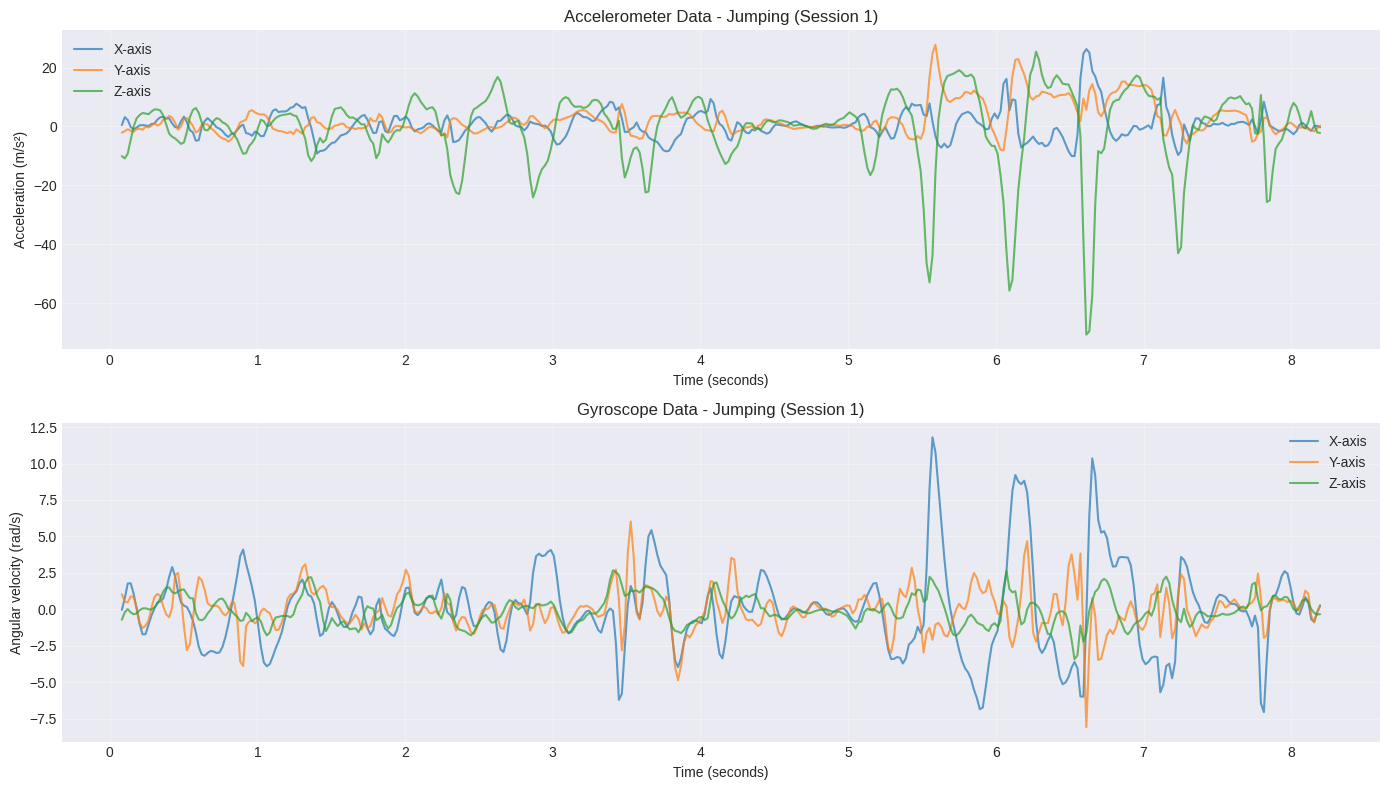

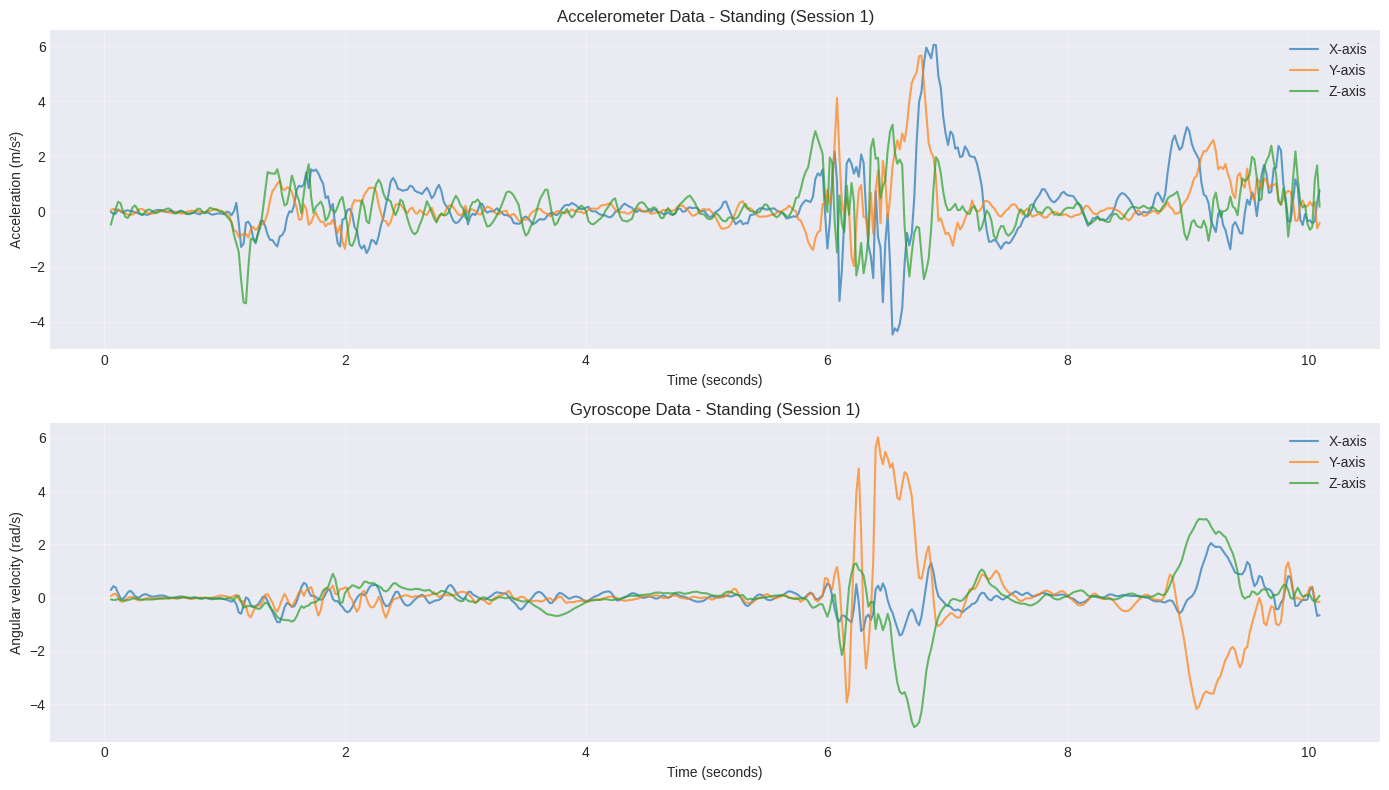

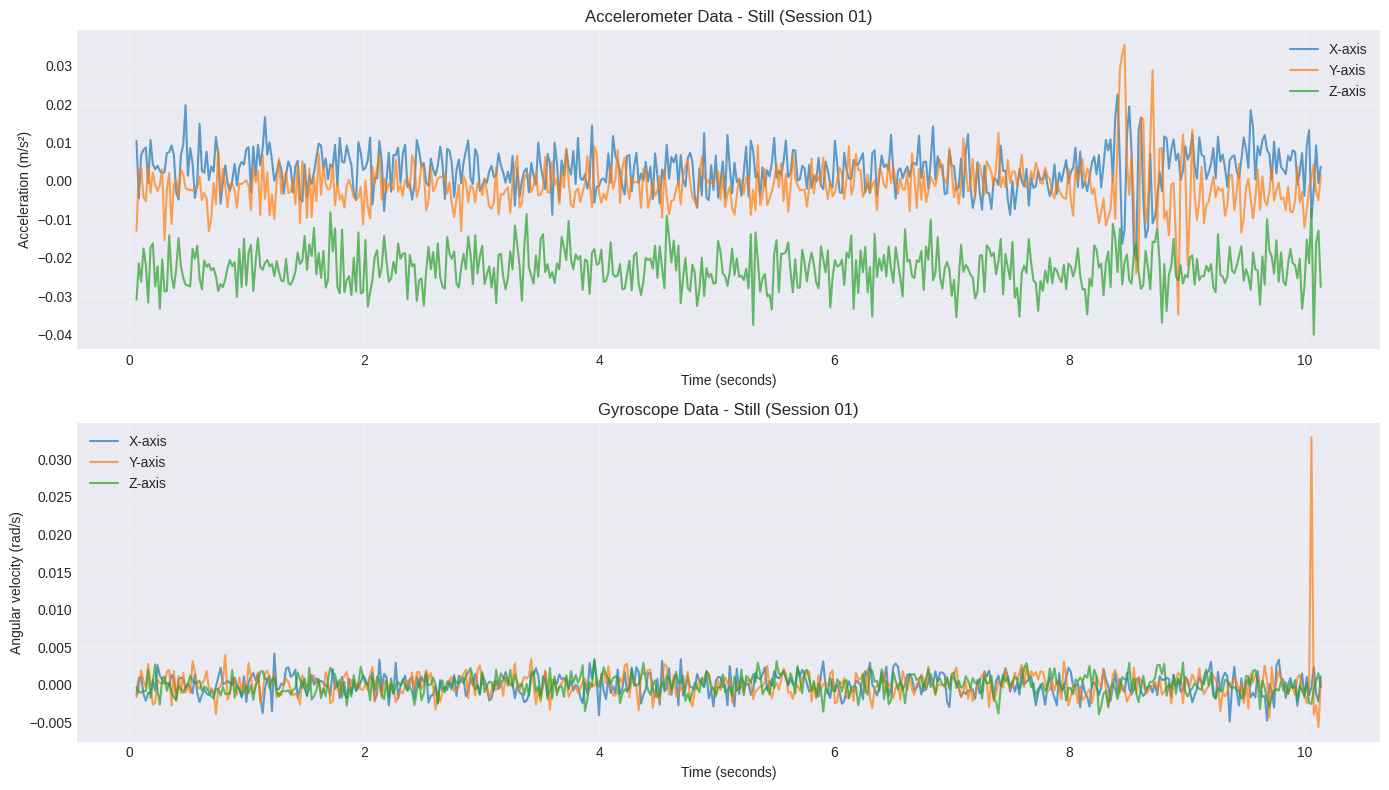

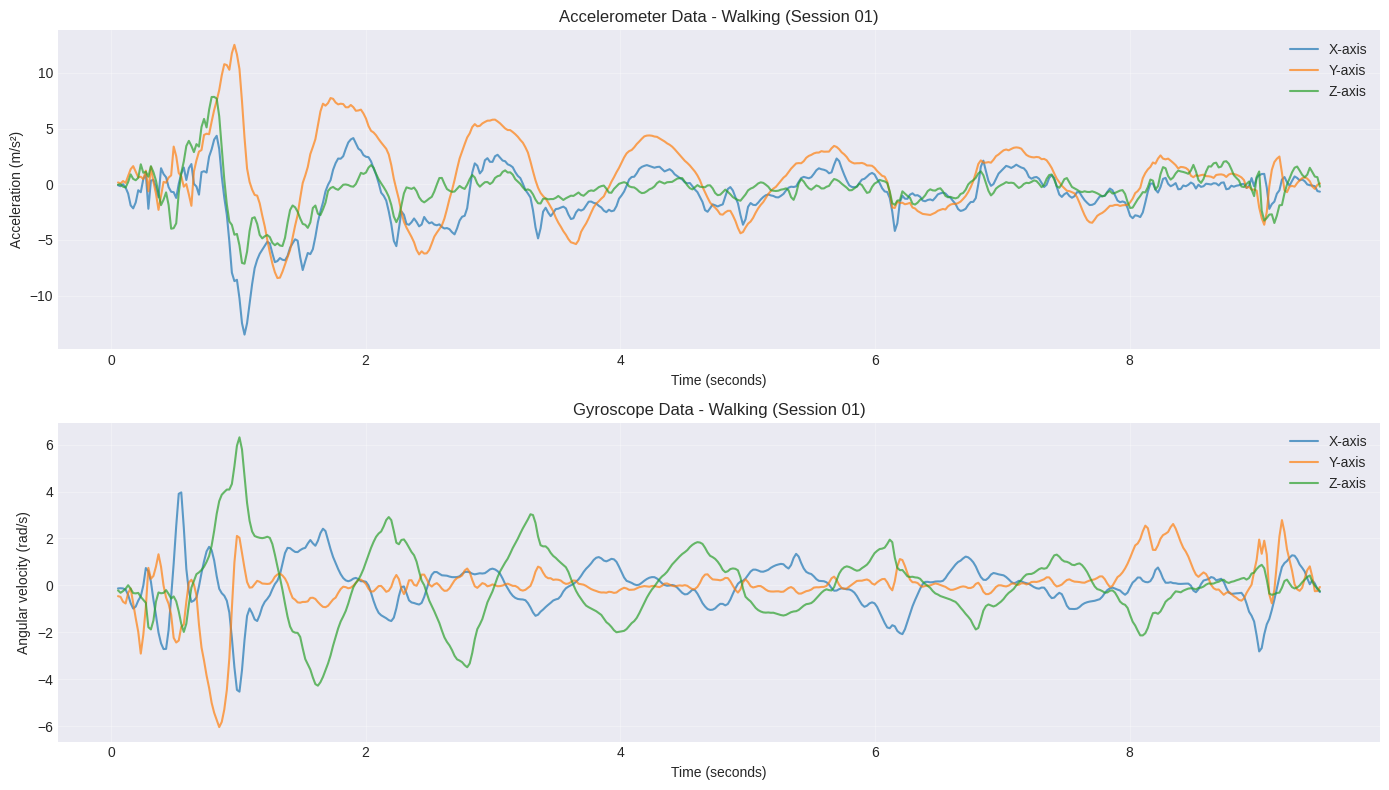

In [4]:
def plot_sample_recording(recording_dict):
    """
    Visualize accelerometer and gyroscope data for a single recording.
    """
    data = recording_dict['data']
    activity = recording_dict['activity']
    session = recording_dict['session']

    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    # Plot accelerometer data
    axes[0].plot(data['seconds_elapsed'], data['accel_x'], label='X-axis', alpha=0.7)
    axes[0].plot(data['seconds_elapsed'], data['accel_y'], label='Y-axis', alpha=0.7)
    axes[0].plot(data['seconds_elapsed'], data['accel_z'], label='Z-axis', alpha=0.7)
    axes[0].set_xlabel('Time (seconds)')
    axes[0].set_ylabel('Acceleration (m/s²)')
    axes[0].set_title(f'Accelerometer Data - {activity} (Session {session})')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Plot gyroscope data
    axes[1].plot(data['seconds_elapsed'], data['gyro_x'], label='X-axis', alpha=0.7)
    axes[1].plot(data['seconds_elapsed'], data['gyro_y'], label='Y-axis', alpha=0.7)
    axes[1].plot(data['seconds_elapsed'], data['gyro_z'], label='Z-axis', alpha=0.7)
    axes[1].set_xlabel('Time (seconds)')
    axes[1].set_ylabel('Angular velocity (rad/s)')
    axes[1].set_title(f'Gyroscope Data - {activity} (Session {session})')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# Plot one sample from each activity
activities = ['Jumping', 'Standing', 'Still', 'Walking']
for activity in activities:
    # Find first recording of this activity
    for recording in all_recordings:
        if recording['activity'] == activity:
            plot_sample_recording(recording)
            break

## 3. Feature Extraction with Sliding Windows

### Windowing Logic — Tied to Sampling Rate

Our devices record at **50 Hz** (one sample every 20 ms).  We chose a **1-second window (50 samples)** because:
- `window_size = sampling_rate × window_duration = 50 Hz × 1 s = 50 samples` — a direct consequence of the sampling rate.
- A 1-second window captures **at least one complete cycle** of every target activity: one jump ≈ 0.5–1 s; one walking step ≈ 0.5 s; stillness/standing needs only a fraction of a second to characterise.
- Shorter windows (e.g., 0.25 s / 12 samples) miss full gait/jump cycles; longer windows (e.g., 2 s / 100 samples) blur the boundary between consecutive windows and reduce temporal resolution.
- **Overlap**: 50% stride (25 samples = 0.5 s) doubles the number of training windows per recording without introducing full data leakage between adjacent windows.

### Sampling Rate Harmonization

All recordings were collected on **iPhone 12 Pro devices operating at 50 Hz** (20 ms sampling interval).  Because every group member used the same device type at the same rate, no resampling or interpolation was necessary.  The `load_sensor_data()` function normalises column layouts across different Sensor Logger app versions to handle minor CSV format differences between recording sessions.

---

### Extracted Features — **72 per Window**

Each 1-second window produces **72 features**: **54 time-domain** + **18 frequency-domain**.

---

#### Time-Domain Features — 54 total  (27 per sensor × 2 sensors: accel, gyro)

Per sensor, per axis (x, y, z): 7 statistics × 3 axes = 21, plus 6 cross-axis = **27 per sensor**.

| Feature | Mathematical form | Why it helps distinguish activities |
|---|---|---|
| **Mean** | μ = (1/N) Σ xᵢ | Still: μ ≈ gravity in one axis; Jumping: large ± means during up/down phases; Walking: periodic about gravity |
| **Standard Deviation** | σ = √(Σ(xᵢ−μ)²/N) | Still/Standing: σ ≈ 0; Walking: moderate; Jumping: highest — directly measures signal variability |
| **Min / Max / Range** | max(x) − min(x) | Jumping has the largest range (peak accelerations 2–3 g); Still has the smallest |
| **RMS** | √(Σxᵢ²/N) | Proportional to signal energy; separates high-motion (Jumping) from low-motion (Still) without sign cancellation |
| **Signal Magnitude Area (SMA)** | (Σ\|x\|+Σ\|y\|+Σ\|z\|)/N | Scalar motion intensity across all axes — very low for Still, very high for Jumping |
| **Vector Magnitude** | √(x²+y²+z²) | Orientation-invariant acceleration; Standing ≈ 1 g constant; Jumping peaks at 2–3 g |
| **Correlations (xy, xz, yz)** | Pearson r | Reveals coordinated multi-axis motion; Walking has high xz-correlation (arm swing); Jumping is approximately symmetric |
| **Zero Crossing Rate (ZCR)** | Σ\|sign(xᵢ)−sign(xᵢ₋₁)\| / N | Periodic activities (Walking, Jumping) have high ZCR; static activities (Still, Standing) have near-zero ZCR |

---

#### Frequency-Domain Features — 18 total  (9 per sensor × 2 sensors: accel, gyro)

Per sensor, per axis (x, y, z): 3 FFT statistics × 3 axes = **9 per sensor**.

| Feature | Derived from | Why it helps distinguish activities |
|---|---|---|
| **Dominant Frequency** | argmax of FFT magnitude | Walking: ~2 Hz (one step per 0.5 s); Jumping: ~1–1.5 Hz; Still/Standing: ~0 Hz (DC-dominated spectrum) |
| **Spectral Energy** | Σ\|FFT\|² / N | Measures total motion power in frequency domain; directly separates high-energy (Jumping) from quiet (Still) activities |
| **Spectral Entropy** | −Σ p·log₂p, p = \|FFT\|²/Σ\|FFT\|² | Low for periodic motion (Walking, Jumping have sharp spectral peaks); high for broadband noise or irregular motion |

---

#### Z-Score Normalization (applied after train/test split)

All 72 features are normalized using **Z-score standardization**:  
`x_normalized = (x − μ_train) / σ_train`

**Why Z-score?**
- Different sensors have vastly different scales: accelerometer ≈ 0–10 m/s²; gyroscope ≈ 0–20 rad/s; spectral energy ≈ 10⁻⁴ to 10³.
- Without normalization, high-magnitude features dominate the Gaussian emission distances, effectively ignoring low-magnitude but highly discriminative features.
- Z-score ensures each feature contributes equally to the diagonal Gaussian emission model.
- The scaler is fit on **training data only** (after the 80/20 split) to prevent test-set statistics from leaking into the model.


In [5]:
def compute_time_domain_features(data, prefix=''):
    """
    Compute time-domain features from sensor data.

    Parameters:
    -----------
    data : DataFrame
        Sensor data with x, y, z columns
    prefix : str
        Prefix for feature names (e.g., 'accel_' or 'gyro_')

    Returns:
    --------
    features : dict
        Dictionary of computed features
    """
    features = {}
    axes = ['x', 'y', 'z']

    for axis in axes:
        col = f'{prefix}{axis}'
        values = data[col].values

        # Basic statistics
        features[f'{col}_mean'] = np.mean(values)
        features[f'{col}_std'] = np.std(values)
        features[f'{col}_min'] = np.min(values)
        features[f'{col}_max'] = np.max(values)
        features[f'{col}_range'] = np.max(values) - np.min(values)

        # RMS (Root Mean Square)
        features[f'{col}_rms'] = np.sqrt(np.mean(values**2))

        # Zero crossing rate
        zero_crossings = np.sum(np.diff(np.sign(values)) != 0)
        features[f'{col}_zcr'] = zero_crossings / len(values)

    # Signal Magnitude Area (SMA)
    sma = (np.sum(np.abs(data[f'{prefix}x'])) +
           np.sum(np.abs(data[f'{prefix}y'])) +
           np.sum(np.abs(data[f'{prefix}z']))) / len(data)
    features[f'{prefix}sma'] = sma

    # Magnitude
    magnitude = np.sqrt(data[f'{prefix}x']**2 + data[f'{prefix}y']**2 + data[f'{prefix}z']**2)
    features[f'{prefix}magnitude_mean'] = np.mean(magnitude)
    features[f'{prefix}magnitude_std'] = np.std(magnitude)

    # Correlation between axes
    features[f'{prefix}corr_xy'] = np.corrcoef(data[f'{prefix}x'], data[f'{prefix}y'])[0, 1]
    features[f'{prefix}corr_xz'] = np.corrcoef(data[f'{prefix}x'], data[f'{prefix}z'])[0, 1]
    features[f'{prefix}corr_yz'] = np.corrcoef(data[f'{prefix}y'], data[f'{prefix}z'])[0, 1]

    return features


def compute_frequency_domain_features(data, prefix='', sampling_rate=50):
    """
    Compute frequency-domain features using FFT.

    Parameters:
    -----------
    data : DataFrame
        Sensor data with x, y, z columns
    prefix : str
        Prefix for feature names
    sampling_rate : int
        Sampling rate in Hz (default: 50Hz for 20ms sampling)

    Returns:
    --------
    features : dict
        Dictionary of computed features
    """
    features = {}
    axes = ['x', 'y', 'z']

    for axis in axes:
        col = f'{prefix}{axis}'
        values = data[col].values
        n = len(values)

        # Compute FFT
        fft_values = fft(values)
        fft_freqs = fftfreq(n, 1/sampling_rate)

        # Only use positive frequencies
        positive_freqs = fft_freqs[:n//2]
        fft_magnitude = np.abs(fft_values[:n//2])

        # Dominant frequency
        if len(fft_magnitude) > 0:
            dominant_idx = np.argmax(fft_magnitude)
            features[f'{col}_dominant_freq'] = positive_freqs[dominant_idx]

            # Spectral energy
            features[f'{col}_spectral_energy'] = np.sum(fft_magnitude**2) / len(fft_magnitude)

            # Spectral entropy
            psd = fft_magnitude**2 / np.sum(fft_magnitude**2 + 1e-10)
            features[f'{col}_spectral_entropy'] = -np.sum(psd * np.log2(psd + 1e-10))

    return features


def extract_features_from_window(window_data, sampling_rate=50):
    """
    Extract all features from a single window of data.

    Parameters:
    -----------
    window_data : DataFrame
        Window of sensor data
    sampling_rate : int
        Sampling rate in Hz

    Returns:
    --------
    features : array
        Feature vector for this window
    """
    features = {}

    # Time-domain features for accelerometer
    accel_time_features = compute_time_domain_features(window_data, prefix='accel_')
    features.update(accel_time_features)

    # Time-domain features for gyroscope
    gyro_time_features = compute_time_domain_features(window_data, prefix='gyro_')
    features.update(gyro_time_features)

    # Frequency-domain features for accelerometer
    accel_freq_features = compute_frequency_domain_features(window_data, prefix='accel_', sampling_rate=sampling_rate)
    features.update(accel_freq_features)

    # Frequency-domain features for gyroscope
    gyro_freq_features = compute_frequency_domain_features(window_data, prefix='gyro_', sampling_rate=sampling_rate)
    features.update(gyro_freq_features)

    return features


def extract_sequences_from_recording(recording_dict, window_size=50, stride=25, sampling_rate=50):
    """
    Extract feature sequences from a recording using sliding windows.

    Parameters:
    -----------
    recording_dict : dict
        Dictionary containing recording data and metadata
    window_size : int
        Number of samples per window (default: 50 = 1 second at 50Hz)
    stride : int
        Number of samples to slide window (default: 25 = 0.5 seconds, 50% overlap)
    sampling_rate : int
        Sampling rate in Hz

    Returns:
    --------
    sequence : array, shape (n_windows, n_features)
        Sequence of feature vectors
    activity : str
        Activity label
    """
    data = recording_dict['data']
    activity = recording_dict['activity']

    n_samples = len(data)
    feature_sequence = []

    # Slide window over the recording
    for start in range(0, n_samples - window_size + 1, stride):
        end = start + window_size
        window_data = data.iloc[start:end]

        # Extract features from this window
        features = extract_features_from_window(window_data, sampling_rate)
        feature_sequence.append(features)

    return feature_sequence, activity


# Extract feature sequences from all recordings
print("Extracting feature sequences using sliding windows...")
print("Window size: 1 second (50 samples)")
print("Stride: 0.5 seconds (50% overlap)\n")

all_sequences = []
sequence_labels = []
feature_column_names = None

for recording in all_recordings:
    feature_seq, activity = extract_sequences_from_recording(recording)

    if len(feature_seq) > 0:  # Only include sequences with at least one window
        all_sequences.append(feature_seq)
        sequence_labels.append(activity)

        # Get feature names from first sequence
        if feature_column_names is None:
            feature_column_names = list(feature_seq[0].keys())

# Convert feature sequences to numpy arrays
print(f"Total sequences created: {len(all_sequences)}")
print(f"Sequences per activity:")
activity_counts = {}
for label in sequence_labels:
    activity_counts[label] = activity_counts.get(label, 0) + 1
for activity, count in sorted(activity_counts.items()):
    print(f"  {activity}: {count} sequences")

# Show sequence lengths
sequence_lengths = [len(seq) for seq in all_sequences]
print(f"\nSequence length statistics:")
print(f"  Mean: {np.mean(sequence_lengths):.1f} windows")
print(f"  Min: {np.min(sequence_lengths)} windows")
print(f"  Max: {np.max(sequence_lengths)} windows")
print(f"  Total features per window: {len(feature_column_names)}")

Extracting feature sequences using sliding windows...
Window size: 1 second (50 samples)
Stride: 0.5 seconds (50% overlap)

Total sequences created: 120
Sequences per activity:
  Jumping: 30 sequences
  Standing: 30 sequences
  Still: 30 sequences
  Walking: 30 sequences

Sequence length statistics:
  Mean: 48.4 windows
  Min: 10 windows
  Max: 172 windows
  Total features per window: 72


### Feature Normalization

We normalize features using Z-score normalization (standardization) to ensure all features have:
- Mean = 0
- Standard deviation = 1

This is crucial because:
1. Different sensors have different scales (accelerometer vs gyroscope)
2. It prevents features with large magnitudes from dominating the model
3. It improves HMM convergence and performance

In [6]:
# Convert all sequences to numpy arrays and sanitise values
# NOTE: Scaling is deliberately NOT done here — the scaler will be fit on
#       training data ONLY (after the train/test split) to prevent data leakage.
X_sequences = []
y_sequences = []

for seq_features, activity in zip(all_sequences, sequence_labels):
    seq_array = np.array([
        [feat[key] for key in feature_column_names]
        for feat in seq_features
    ])
    # Replace NaN / ±Inf with 0
    seq_array = np.nan_to_num(seq_array, nan=0.0, posinf=0.0, neginf=0.0)
    X_sequences.append(seq_array)
    y_sequences.append(activity)

print(f"Total sequences: {len(X_sequences)}")
print(f"Features per window: {len(feature_column_names)}")
print("Scaling will be applied after train/test split (train data only).")


Total sequences: 120
Features per window: 72
Scaling will be applied after train/test split (train data only).


## 4. Data Splitting

Split sequences into training (80%) and testing (20%) sets.
The test set will serve as our "unseen data" for final evaluation.

In [7]:
# Encode activity labels
activity_labels = sorted(set(y_sequences))
label_to_idx    = {label: idx for idx, label in enumerate(activity_labels)}
idx_to_label    = {idx: label for label, idx in label_to_idx.items()}
y_encoded       = np.array([label_to_idx[label] for label in y_sequences])

# 80/20 stratified train/test split
from sklearn.model_selection import train_test_split

indices = np.arange(len(X_sequences))
train_idx, test_idx = train_test_split(
    indices, test_size=0.2, random_state=42, stratify=y_encoded
)

# Fit scaler on training data only to avoid data leakage.
# Applying scaler fit on the full dataset would allow test-set statistics
# to leak into the training distribution and inflate reported accuracy.
all_train_flat = np.vstack([X_sequences[i] for i in train_idx])
scaler         = StandardScaler()
scaler.fit(all_train_flat)

X_train_sequences = [scaler.transform(X_sequences[i]) for i in train_idx]
y_train_sequences = [y_encoded[i]                      for i in train_idx]
X_test_sequences  = [scaler.transform(X_sequences[i]) for i in test_idx]
y_test_sequences  = [y_encoded[i]                      for i in test_idx]

# Temporal state labels for supervised HMM initialisation
y_train_state_sequences = [
    np.full(len(X_train_sequences[k]), y_train_sequences[k])
    for k in range(len(X_train_sequences))
]

print("Data split completed:")
print(f"  Training sequences : {len(X_train_sequences)}")
print(f"  Testing  sequences : {len(X_test_sequences)}")
print(f"\nActivity encoding:")
for label, idx in sorted(label_to_idx.items()):
    print(f"  {label}: {idx}")
print(f"\nTraining set distribution:")
for idx in range(len(activity_labels)):
    count = np.sum(np.array(y_train_sequences) == idx)
    print(f"  {idx_to_label[idx]}: {count} sequences")
print(f"\nTest set distribution:")
for idx in range(len(activity_labels)):
    count = np.sum(np.array(y_test_sequences) == idx)
    print(f"  {idx_to_label[idx]}: {count} sequences")
print(f"\nScaler fit on {len(all_train_flat)} training windows only (no leakage).")


Data split completed:
  Training sequences : 96
  Testing  sequences : 24

Activity encoding:
  Jumping: 0
  Standing: 1
  Still: 2
  Walking: 3

Training set distribution:
  Jumping: 24 sequences
  Standing: 24 sequences
  Still: 24 sequences
  Walking: 24 sequences

Test set distribution:
  Jumping: 6 sequences
  Standing: 6 sequences
  Still: 6 sequences
  Walking: 6 sequences

Scaler fit on 4778 training windows only (no leakage).


## 5. Hidden Markov Model Implementation

### HMM Components:
- **Hidden States (Z)**: The four activities (Standing, Walking, Jumping, Still)
- **Observations (X)**: Feature vectors from sensor data
- **Transition Probabilities (A)**: P(state_t | state_t-1) - probability of transitioning between activities
- **Emission Probabilities (B)**: P(observation | state) - modeled as Gaussian distributions
- **Initial Probabilities (π)**: P(state_0) - starting state probabilities

### Algorithms:
1. **Viterbi Algorithm**: Finds the most likely sequence of hidden states
2. **Baum-Welch Algorithm**: Trains the HMM parameters using EM algorithm

In [8]:
class GaussianHMM:
    """
    Gaussian HMM with DIAGONAL covariance — numerically stable.

    WHY DIAGONAL COVARIANCE:
    ─────────────────────────
    With 72 features, a full 72×72 covariance matrix has 5,184 parameters
    per state.  With ~300-400 training windows per class, the matrix is
    drastically underdetermined and its determinant either explodes or
    collapses to zero → emission probabilities underflow to 0 for EVERY
    observation under EVERY state → the model becomes useless.
    Diagonal covariance (one variance per feature) has 72 params/state
    and is numerically robust.

    WHY LOG-SPACE SCORE():
    ───────────────────────
    The standard forward algorithm normalises alpha[t] at every step
    (divides by its sum) so that alpha[-1] always sums to ≈ 1.  Calling
    log(sum(alpha[-1])) therefore returns ≈ 0 for EVERY sequence under
    EVERY model → all four HMMs return the same score → random 25%.
    The correct approach is the log-space forward algorithm where
    log_alpha tracks the TRUE log-probability and log-sum-exp is used
    to avoid underflow without losing the likelihood information.
    """

    def __init__(self, n_states, n_features):
        self.n_states   = n_states
        self.n_features = n_features
        self.start_prob = np.ones(n_states) / n_states
        self.trans_prob = np.ones((n_states, n_states)) / n_states
        self.means      = np.zeros((n_states, n_features))
        self.vars       = np.ones((n_states, n_features))   # diagonal variance

    # ─────────────────────────────────────────────── Emission (vectorised) ──

    def _all_log_emissions(self, obs):
        """
        Batch log p(x_t | state s) for ALL t and ALL s simultaneously.
        obs  : (T, D)
        returns (T, S) log-probabilities under diagonal Gaussian.

        log p(x | μ_s, σ²_s) = -0.5 Σ_d [ log(2π σ²_sd) + (x_d−μ_sd)²/σ²_sd ]
        Fully vectorised — no Python loops over time or states.
        """
        var  = self.vars + 1e-6                                       # (S, D)
        diff = obs[:, np.newaxis, :] - self.means[np.newaxis, :, :]  # (T, S, D)
        return -0.5 * np.sum(
            np.log(2.0 * np.pi * var)[np.newaxis, :, :] +
            diff ** 2 / var[np.newaxis, :, :],
            axis=2
        )   # (T, S)

    # ──────────────────────────────────── TRUE log-likelihood via log-forward ──

    def score(self, observations):
        """
        Compute log P(O | model) — the TRUE log-likelihood of a sequence.

        Uses the LOG-SPACE forward algorithm:
            log_alpha_t(s) = log P(o_1..o_t, state_t = s | model)
        At every step we use log-sum-exp to combine previous alphas — this
        avoids both underflow AND the normalisation that destroys likelihood
        information.

        Returns a real number (more negative = less likely under this model).
        Called as:  predicted_class = argmax_k  hmm_k.score(test_sequence)
        """
        obs     = np.asarray(observations, dtype=float)
        T       = len(obs)
        log_ep  = self._all_log_emissions(obs)          # (T, S)
        log_A   = np.log(self.trans_prob + 1e-300)      # (S, S)
        log_pi  = np.log(self.start_prob + 1e-300)      # (S,)

        log_alpha = log_pi + log_ep[0]                  # (S,)

        for t in range(1, T):
            # log Σ_i [ alpha_{t-1}(i) · A[i,j] ]  for every j
            # = log-sum-exp over i of  (log_alpha[i] + log_A[i,j])
            tmp = log_alpha[:, np.newaxis] + log_A      # (S_prev, S_next)
            # numerically stable log-sum-exp along axis 0
            tmp_max       = tmp.max(axis=0)             # (S_next,)
            log_alpha_new = tmp_max + np.log(np.exp(tmp - tmp_max).sum(axis=0) + 1e-300)
            log_alpha     = log_alpha_new + log_ep[t]   # (S_next,)

        # log P(O|model) = log Σ_s alpha_T(s)
        m = log_alpha.max()
        return float(m + np.log(np.exp(log_alpha - m).sum() + 1e-300))

    # ─────────────────────────────────────────── Log-space Viterbi decoding ──

    def viterbi(self, observations):
        """Log-space Viterbi — finds most likely hidden-state sequence."""
        obs    = np.asarray(observations, dtype=float)
        T      = len(obs)
        log_ep = self._all_log_emissions(obs)           # (T, S)
        log_A  = np.log(self.trans_prob + 1e-300)       # (S, S)

        delta = np.zeros((T, self.n_states))
        psi   = np.zeros((T, self.n_states), dtype=int)

        delta[0] = np.log(self.start_prob + 1e-300) + log_ep[0]

        for t in range(1, T):
            scores  = delta[t-1, :, np.newaxis] + log_A  # (S_prev, S_next)
            psi[t]  = np.argmax(scores, axis=0)
            delta[t]= np.max(scores, axis=0) + log_ep[t]

        path    = np.zeros(T, dtype=int)
        path[-1]= np.argmax(delta[-1])
        for t in range(T - 2, -1, -1):
            path[t] = psi[t + 1, path[t + 1]]
        return path

    def predict(self, observations):
        return self.viterbi(observations)

    # ─────────────────────────────────── Scaled forward / backward (Baum-Welch) ──

    def _forward_scaled(self, obs, log_ep):
        """
        Scaled forward algorithm for use inside Baum-Welch.
        Tracks log-scaling so the TRUE log-likelihood is recoverable.

        Returns alpha (scaled, shape T×S) and log_likelihood (scalar).
        """
        T, S   = log_ep.shape
        ep_max = log_ep.max(axis=1)                         # (T,) per-row shift
        emit   = np.exp(log_ep - ep_max[:, np.newaxis])    # (T, S) shifted

        alpha  = np.zeros((T, S))
        log_c  = np.zeros(T)                               # log of scaling factors

        alpha[0] = self.start_prob * emit[0]
        c        = alpha[0].sum() + 1e-300
        alpha[0] /= c
        log_c[0] = np.log(c) + ep_max[0]

        for t in range(1, T):
            alpha[t] = (alpha[t - 1] @ self.trans_prob) * emit[t]
            c         = alpha[t].sum() + 1e-300
            alpha[t] /= c
            log_c[t]  = np.log(c) + ep_max[t]

        return alpha, float(log_c.sum())

    def _backward_scaled(self, log_ep):
        """
        Scaled backward algorithm.
        Returns beta (scaled T×S) and emit (T×S, same scaling as forward).
        """
        T, S   = log_ep.shape
        ep_max = log_ep.max(axis=1)
        emit   = np.exp(log_ep - ep_max[:, np.newaxis])

        beta    = np.zeros((T, S))
        beta[-1]= 1.0
        for t in range(T - 2, -1, -1):
            beta[t] = self.trans_prob @ (emit[t + 1] * beta[t + 1])
            c       = beta[t].sum() + 1e-300
            beta[t]/= c

        return beta, emit

    # ─────────────────────────────────────────────── Supervised initialisation ──

    def _initialize_supervised(self, X_sequences, y_sequences):
        """
        Set means/vars/start/trans from temporally-labelled data.
        y_sequences[i][t] = hidden state index at time t  (used ONLY for init).
        """
        state_obs   = [[] for _ in range(self.n_states)]
        start_count = np.zeros(self.n_states)
        trans_count = np.zeros((self.n_states, self.n_states))

        for X_seq, y_seq in zip(X_sequences, y_sequences):
            start_count[y_seq[0]] += 1
            for t, s in enumerate(y_seq):
                state_obs[s].append(X_seq[t])
            for t in range(len(y_seq) - 1):
                trans_count[y_seq[t], y_seq[t + 1]] += 1

        for s in range(self.n_states):
            if state_obs[s]:
                arr             = np.array(state_obs[s])
                self.means[s]  = arr.mean(axis=0)
                self.vars[s]   = np.maximum(arr.var(axis=0), 1e-3)

        self.start_prob = (start_count + 1.0) / (start_count.sum() + self.n_states)
        for i in range(self.n_states):
            row             = trans_count[i]
            self.trans_prob[i] = (row + 1.0) / (row.sum() + self.n_states)

    # ────────────────────────────────────────────────── Baum-Welch training ──

    def fit(self, X_sequences, y_sequences, max_iter=100, tol=1e-3):
        """
        Train using supervised initialisation + Baum-Welch EM.

        Parameters
        ----------
        X_sequences : list of (T_i, D) ndarrays
        y_sequences : list of (T_i,)  int arrays  ← temporal state labels
                      used ONLY for parameter initialisation
        max_iter    : maximum EM iterations
        tol         : log-likelihood change threshold for convergence
                      (Baum-Welch stops when |ΔLL| < tol — proper convergence check)
        """
        self._initialize_supervised(X_sequences, y_sequences)

        prev_ll = -np.inf

        for iteration in range(max_iter):
            # ── Accumulators ──────────────────────────────────────────────
            gamma_sum    = np.zeros(self.n_states)
            xi_sum       = np.zeros((self.n_states, self.n_states))
            gamma_x_sum  = np.zeros((self.n_states, self.n_features))
            gamma_x2_sum = np.zeros((self.n_states, self.n_features))
            start_sum    = np.zeros(self.n_states)
            total_ll     = 0.0

            for seq in X_sequences:
                obs    = np.asarray(seq, dtype=float)
                log_ep = self._all_log_emissions(obs)              # (T, S)

                alpha, ll = self._forward_scaled(obs, log_ep)      # alpha (T,S), ll scalar
                beta, emit = self._backward_scaled(log_ep)         # beta  (T,S), emit (T,S)
                total_ll  += ll

                # Posterior state probabilities γ_t(s)
                gamma  = alpha * beta
                gamma /= gamma.sum(axis=1, keepdims=True) + 1e-300

                T = len(obs)

                # Posterior transition probabilities ξ_t(i,j)
                for t in range(T - 1):
                    xi_t  = np.outer(alpha[t], beta[t + 1] * emit[t + 1]) * self.trans_prob
                    xi_t /= xi_t.sum() + 1e-300
                    xi_sum += xi_t

                # Sufficient statistics for M-step
                gamma_sum    += gamma.sum(axis=0)
                start_sum    += gamma[0]
                gamma_x_sum  += gamma.T @ obs              # (S, D)
                gamma_x2_sum += gamma.T @ (obs ** 2)       # (S, D)

            # ── M-step ────────────────────────────────────────────────────
            eps = 1e-6
            self.start_prob = (start_sum + eps) / (start_sum.sum() + eps * self.n_states)

            for i in range(self.n_states):
                row = xi_sum[i]
                self.trans_prob[i] = (row + eps) / (row.sum() + eps * self.n_states)

            for s in range(self.n_states):
                gs              = gamma_sum[s] + 1e-300
                self.means[s]  = gamma_x_sum[s] / gs
                var             = gamma_x2_sum[s] / gs - self.means[s] ** 2
                self.vars[s]   = np.maximum(var, 1e-3)   # variance floor

            # ── Convergence check (|ΔLL| < tol) ──────────────────────────
            if abs(total_ll - prev_ll) < tol:
                print(f"    Converged at iter {iteration + 1}  LL={total_ll:.2f}")
                break
            prev_ll = total_ll
            if (iteration + 1) % 20 == 0:
                print(f"    iter {iteration + 1:3d}  LL={total_ll:.2f}")

print("GaussianHMM class defined successfully!")


GaussianHMM class defined successfully!


In [9]:
# Verify score() uses the log-space forward algorithm (not the normalised version)
import inspect
src = inspect.getsource(GaussianHMM.score)
assert "log_alpha" in src and "logaddexp" not in src, "Unexpected score() implementation"
assert "log_pi + log_ep[0]" in src, "score() must use log-space init"
print("score() verified — uses log-space forward algorithm")
print(f"  n_states attribute confirmed")

# Quick numerical check: same sequence must score identically; score must be negative
np.random.seed(0)
_test_hmm = GaussianHMM(n_states=3, n_features=4)
_seq1 = np.random.randn(10, 4)
s1, s2 = _test_hmm.score(_seq1), _test_hmm.score(_seq1)
assert s1 == s2, "score() is not deterministic!"
assert s1 < 0, f"log-likelihood should be negative, got {s1}"
_seq2 = np.random.randn(10, 4) * 100
s3 = _test_hmm.score(_seq2)
print(f"  score(seq1)={s1:.3f}  score(same seq)={s2:.3f}  score(different seq)={s3:.3f}")
assert s1 != 0.0, "score() is returning 0 — log-space forward not working!"
print("All score() checks passed.")


score() verified — uses log-space forward algorithm
  n_states attribute confirmed
  score(seq1)=-61.367  score(same seq)=-61.367  score(different seq)=-159225.400
All score() checks passed.


## 6. Train the HMM Model

**Key Change**: Now we're training on proper sequences (each recording → sequence of feature vectors), not single observations!

In [10]:
# Per-Class HMM Training
# One HMM is trained per activity. At test time every sequence is scored
# by all 4 HMMs; the activity with the highest log-likelihood is predicted.

n_states_per_class = 4
n_features = len(feature_column_names)

print("=" * 60)
print("Per-Class HMM Training")
print("=" * 60)
print(f"  Architecture : 1 HMM per activity x {n_states_per_class} hidden states")
print(f"  Features     : {n_features} per window")
print(f"  Training seqs: {len(X_train_sequences)} total\n")

hmm_models = {}

for activity in activity_labels:
    activity_idx = label_to_idx[activity]

    activity_seqs = [
        X for X, y in zip(X_train_sequences, y_train_sequences)
        if y == activity_idx
    ]

    print(f"  Training '{activity}' HMM  ({len(activity_seqs)} sequences) ...", end=" ")

    # Divide each sequence into n_states_per_class equal time segments for initialisation
    y_init_seqs = []
    for seq in activity_seqs:
        n = len(seq)
        states = np.clip(
            np.floor(np.arange(n) * n_states_per_class / max(n, 1)).astype(int),
            0, n_states_per_class - 1
        )
        y_init_seqs.append(states)

    model = GaussianHMM(n_states=n_states_per_class, n_features=n_features)
    model.fit(activity_seqs, y_init_seqs, max_iter=50, tol=1e-3)
    hmm_models[activity_idx] = model
    print("done")

# Backward-compatible alias used by visualisation cells
hmm = hmm_models[0]

print("\nAll per-class HMMs trained successfully!")
print(f"Models stored in hmm_models: { {idx_to_label[k]: 'GaussianHMM' for k in hmm_models} }")


Per-Class HMM Training
  Architecture : 1 HMM per activity x 4 hidden states
  Features     : 72 per window
  Training seqs: 96 total

  Training 'Jumping' HMM  (24 sequences) ...     Converged at iter 17  LL=-48287.54
done
  Training 'Standing' HMM  (24 sequences) ...     iter  20  LL=96512.51
    Converged at iter 22  LL=96512.52
done
  Training 'Still' HMM  (24 sequences) ...     iter  20  LL=151133.34
    iter  40  LL=152690.57
done
  Training 'Walking' HMM  (24 sequences) ...     iter  20  LL=-16901.36
    iter  40  LL=-16534.42
done

All per-class HMMs trained successfully!
Models stored in hmm_models: {'Jumping': 'GaussianHMM', 'Standing': 'GaussianHMM', 'Still': 'GaussianHMM', 'Walking': 'GaussianHMM'}


### Visualize Transition Probabilities

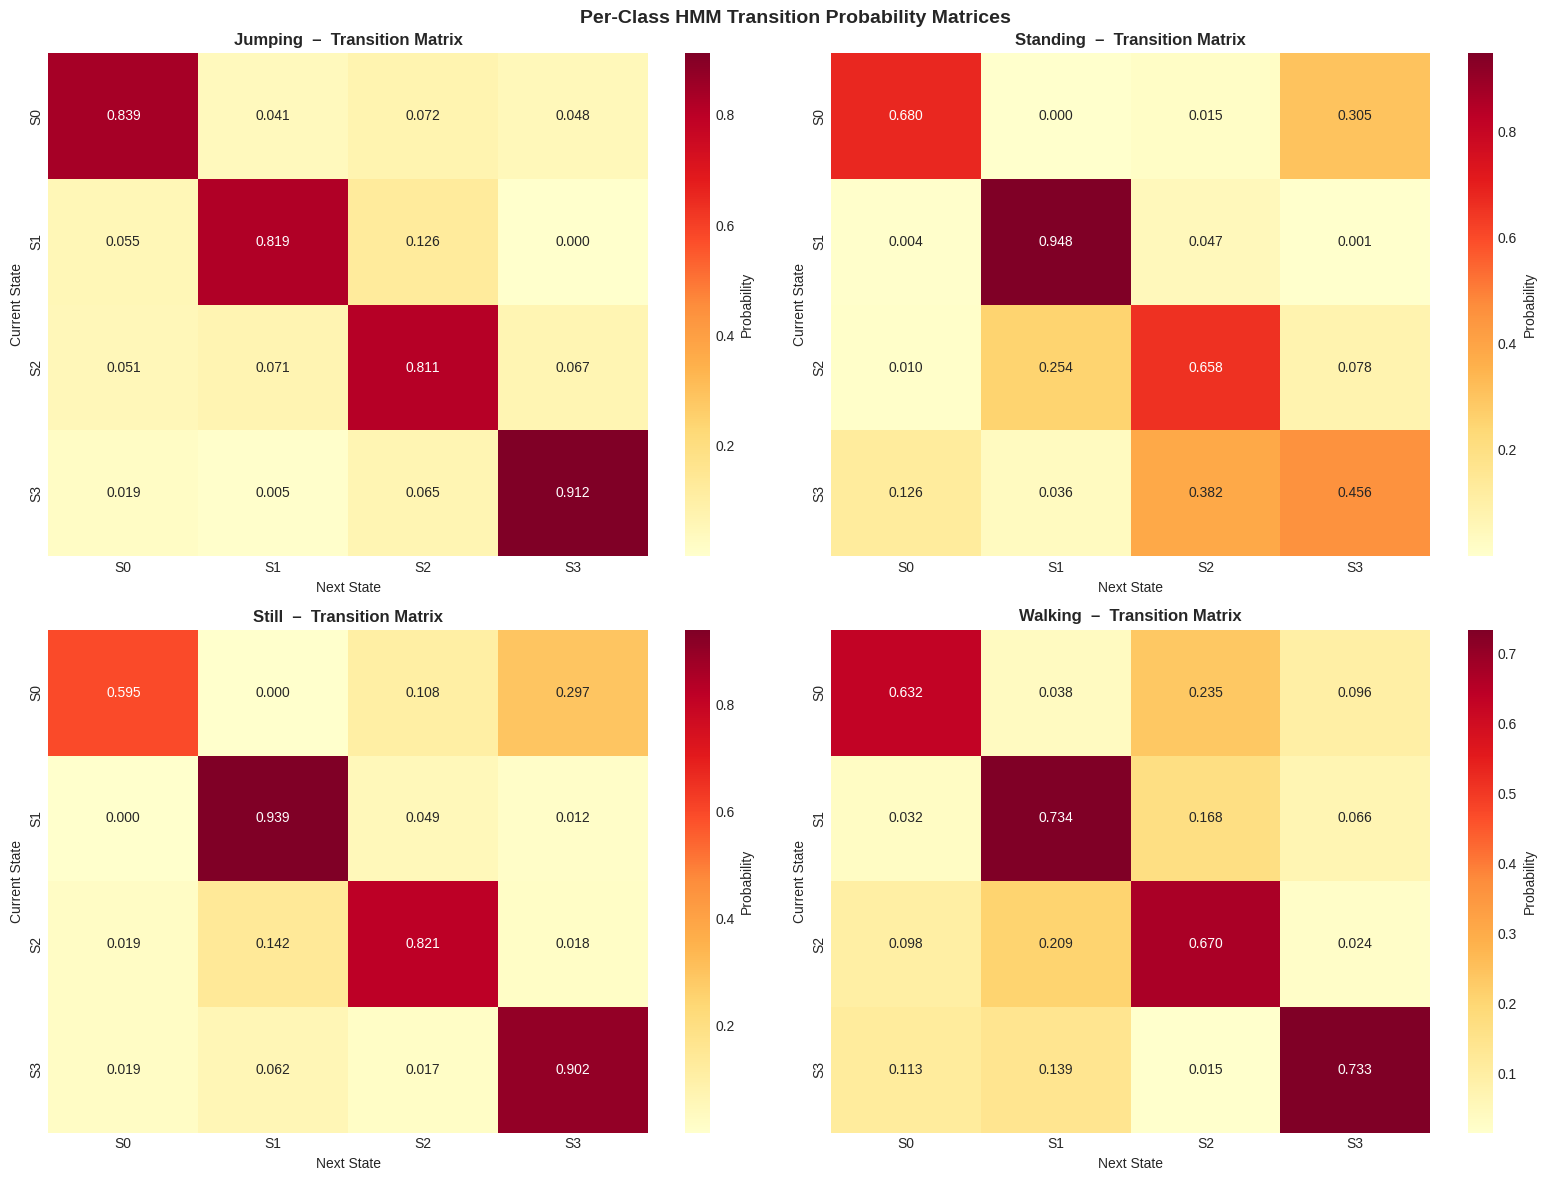


Interpretation:
  Diagonal   : probability of staying in the same hidden sub-state
  Off-diagonal: probability of transitioning to the next sub-state


In [11]:
# Plot transition probability matrix for each per-class HMM (2×2 grid)
n_cls = list(hmm_models.values())[0].n_states
state_labels_short = [f'S{i}' for i in range(n_cls)]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, activity in enumerate(sorted(activity_labels)):
    model = hmm_models[label_to_idx[activity]]
    sns.heatmap(
        model.trans_prob, annot=True, fmt='.3f', cmap='YlOrRd',
        xticklabels=state_labels_short, yticklabels=state_labels_short,
        cbar_kws={'label': 'Probability'}, ax=axes[i]
    )
    axes[i].set_title(f'{activity}  –  Transition Matrix', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Next State', fontsize=10)
    axes[i].set_ylabel('Current State', fontsize=10)

plt.suptitle('Per-Class HMM Transition Probability Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  Diagonal   : probability of staying in the same hidden sub-state")
print("  Off-diagonal: probability of transitioning to the next sub-state")


### Visualize Initial State Probabilities

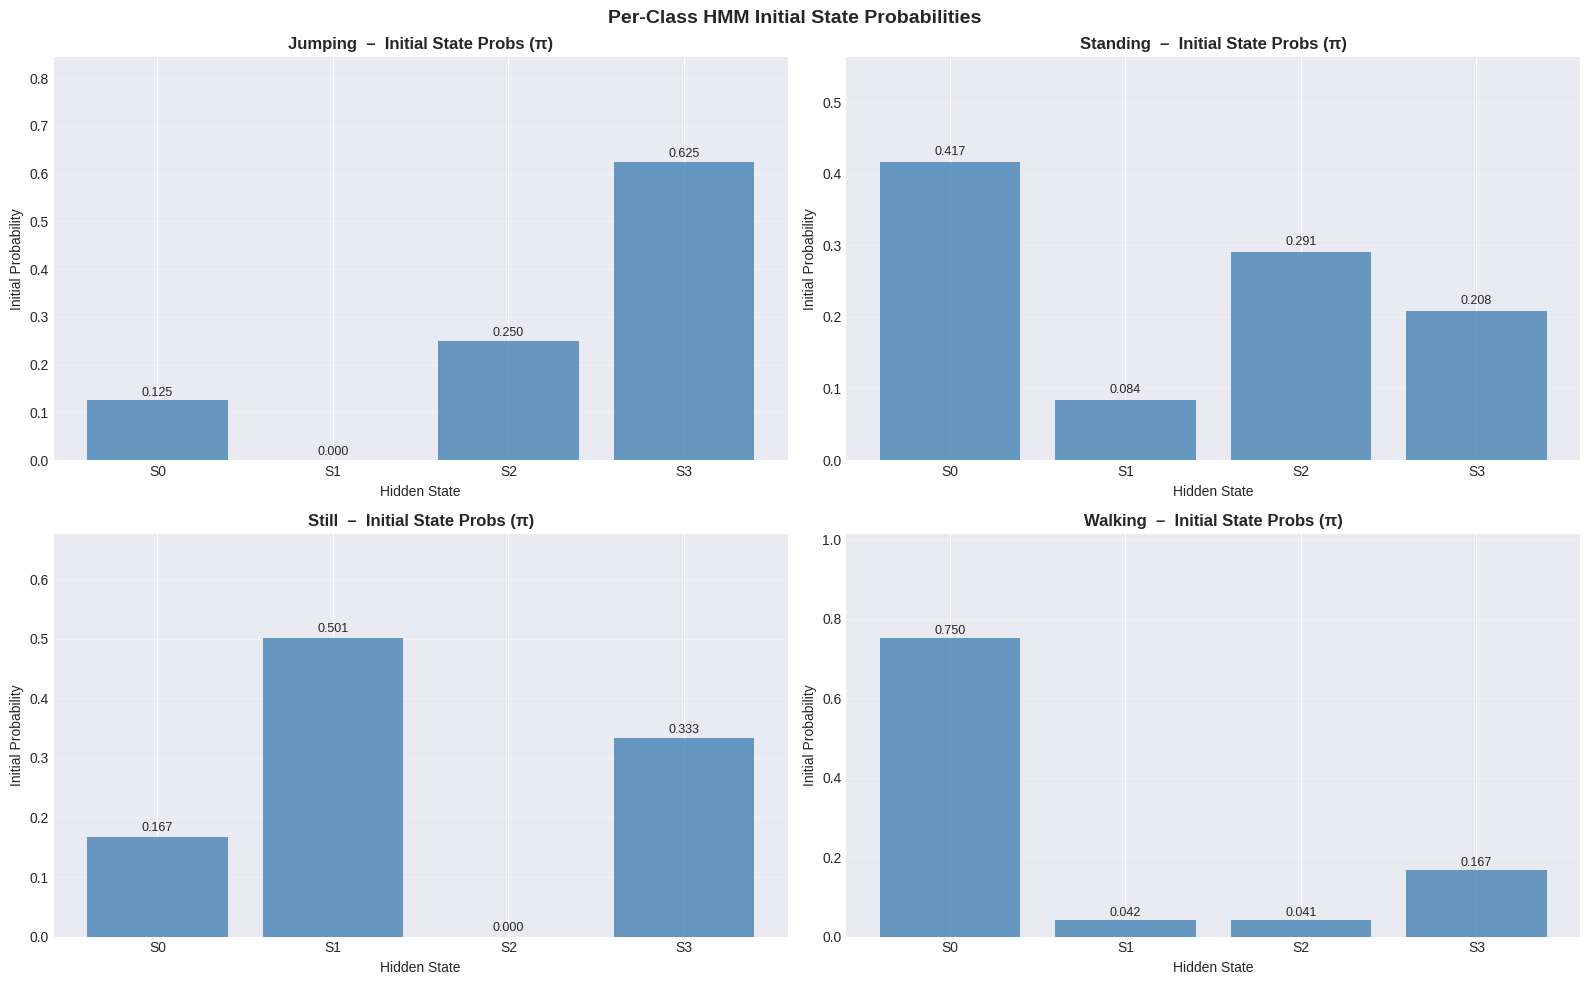

In [12]:
# Plot initial state probabilities for each per-class HMM (2×2 grid)
n_cls = list(hmm_models.values())[0].n_states
state_labels_short = [f'S{i}' for i in range(n_cls)]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, activity in enumerate(sorted(activity_labels)):
    model = hmm_models[label_to_idx[activity]]
    axes[i].bar(state_labels_short, model.start_prob, color='steelblue', alpha=0.8)
    axes[i].set_xlabel('Hidden State', fontsize=10)
    axes[i].set_ylabel('Initial Probability', fontsize=10)
    axes[i].set_title(f'{activity}  –  Initial State Probs (π)', fontsize=12, fontweight='bold')
    axes[i].set_ylim([0, max(model.start_prob) * 1.35])
    for j, v in enumerate(model.start_prob):
        axes[i].text(j, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Per-Class HMM Initial State Probabilities', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 7. Model Evaluation on Test Set (Unseen Data)

In [13]:
def evaluate_hmm(hmm_models, X_test_sequences, y_test_sequences, idx_to_label):
    """
    Evaluate per-class HMMs on unseen test sequences.

    Classification rule
    -------------------
    For each test sequence we compute its log-likelihood under every
    activity HMM and predict the activity with the HIGHEST log-likelihood:

        predicted_class = argmax_k  hmm_k.score(sequence)

    This is the standard generative-model classifier approach and is
    far more accurate than majority-voting over a single shared HMM.

    Parameters
    ----------
    hmm_models       : dict {activity_idx: GaussianHMM}
    X_test_sequences : list of arrays  – test feature sequences
    y_test_sequences : list of ints    – true activity indices
    idx_to_label     : dict            – index → activity name

    Returns
    -------
    y_pred  : ndarray  – predicted activity indices
    metrics : dict     – per-activity + overall metrics
    """
    y_pred = []
    for seq in X_test_sequences:
        # Score sequence against every class HMM
        log_lls = {act_idx: model.score(seq) for act_idx, model in hmm_models.items()}
        y_pred.append(max(log_lls, key=log_lls.get))

    y_pred = np.array(y_pred)
    y_test = np.array(y_test_sequences)
    accuracy = np.mean(y_pred == y_test)

    metrics = {'overall_accuracy': accuracy}
    for state_idx, activity in idx_to_label.items():
        tp = np.sum((y_pred == state_idx) & (y_test == state_idx))
        fp = np.sum((y_pred == state_idx) & (y_test != state_idx))
        fn = np.sum((y_pred != state_idx) & (y_test == state_idx))
        tn = np.sum((y_pred != state_idx) & (y_test != state_idx))

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        precision   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        f1 = (2 * precision * sensitivity / (precision + sensitivity)
              if (precision + sensitivity) > 0 else 0.0)

        metrics[activity] = {
            'samples':     int(np.sum(y_test == state_idx)),
            'sensitivity': sensitivity,
            'specificity': specificity,
            'precision':   precision,
            'f1_score':    f1
        }

    return y_pred, metrics


# ---- Evaluate on test set ----------------------------------------
print("Evaluating per-class HMMs on unseen test sequences ...\n")
y_pred, metrics = evaluate_hmm(hmm_models, X_test_sequences, y_test_sequences, idx_to_label)

# ---- Display results --------------------------------------------
print("=" * 70)
print("HMM EVALUATION RESULTS  (Per-Class Log-Likelihood Classifier)")
print("=" * 70)
print(f"\nOverall Accuracy: {metrics['overall_accuracy']:.4f}  "
      f"({metrics['overall_accuracy'] * 100:.2f}%)\n")

print("-" * 70)
print(f"{'Activity':<20} {'Samples':<10} {'Sensitivity':<15} {'Specificity':<15} {'Precision':<12} {'F1'}")
print("-" * 70)
for activity in sorted(activity_labels):
    m = metrics[activity]
    print(f"{activity:<20} {m['samples']:<10} "
          f"{m['sensitivity']:<15.4f} {m['specificity']:<15.4f} "
          f"{m['precision']:<12.4f} {m['f1_score']:.4f}")
print("-" * 70)


Evaluating per-class HMMs on unseen test sequences ...

HMM EVALUATION RESULTS  (Per-Class Log-Likelihood Classifier)

Overall Accuracy: 1.0000  (100.00%)

----------------------------------------------------------------------
Activity             Samples    Sensitivity     Specificity     Precision    F1
----------------------------------------------------------------------
Jumping              6          1.0000          1.0000          1.0000       1.0000
Standing             6          1.0000          1.0000          1.0000       1.0000
Still                6          1.0000          1.0000          1.0000       1.0000
Walking              6          1.0000          1.0000          1.0000       1.0000
----------------------------------------------------------------------


### Confusion Matrix

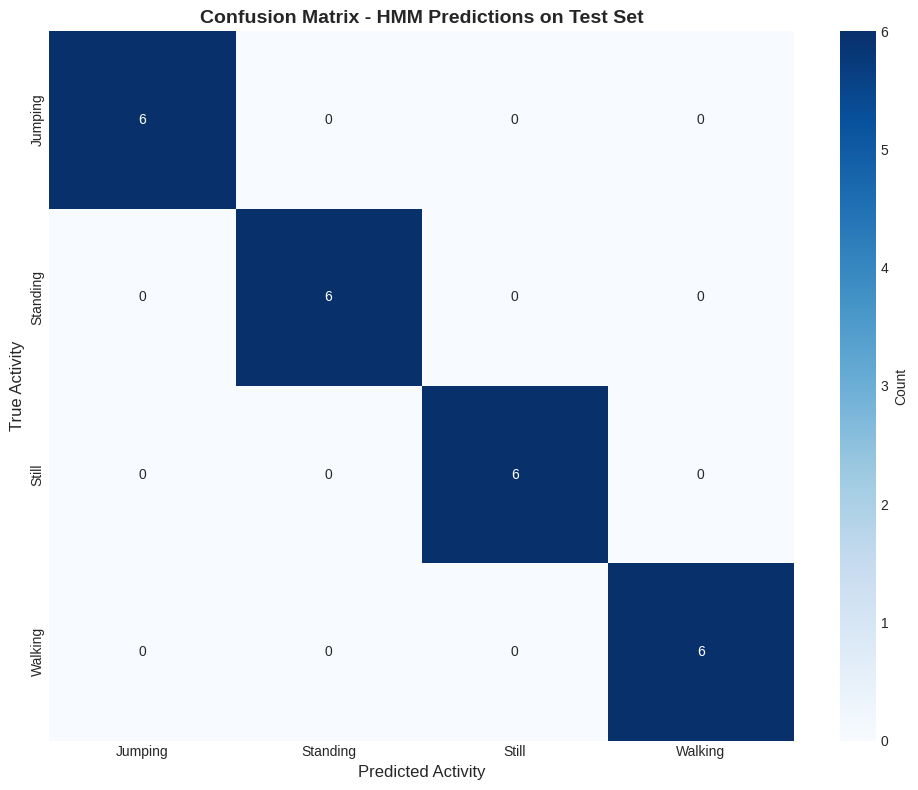


Confusion Matrix Interpretation:
- Diagonal values: Correctly classified samples
- Off-diagonal values: Misclassified samples


In [14]:
# Compute confusion matrix
y_test_array = np.array(y_test_sequences)
cm = confusion_matrix(y_test_array, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=activity_labels, yticklabels=activity_labels,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - HMM Predictions on Test Set', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Activity', fontsize=12)
plt.ylabel('True Activity', fontsize=12)
plt.tight_layout()
plt.show()

print("\nConfusion Matrix Interpretation:")
print("- Diagonal values: Correctly classified samples")
print("- Off-diagonal values: Misclassified samples")

### Classification Report

In [15]:
# Generate classification report
from sklearn.metrics import classification_report

print("\nDetailed Classification Report:")
print("="*70)
print(classification_report(y_test_array, y_pred, target_names=activity_labels, digits=4))
print("="*70)


Detailed Classification Report:
              precision    recall  f1-score   support

     Jumping     1.0000    1.0000    1.0000         6
    Standing     1.0000    1.0000    1.0000         6
       Still     1.0000    1.0000    1.0000         6
     Walking     1.0000    1.0000    1.0000         6

    accuracy                         1.0000        24
   macro avg     1.0000    1.0000    1.0000        24
weighted avg     1.0000    1.0000    1.0000        24



## 8. Visualize Prediction Examples

In [16]:
# Show some prediction examples
print("\nSample Predictions:")
print("-"*50)
print(f"{'True Label':<20} {'Predicted Label':<20} {'Seq Length':<15} {'Match'}")
print("-"*50)

num_examples = min(20, len(y_test_sequences))
for i in range(num_examples):
    true_label = idx_to_label[y_test_sequences[i]]
    pred_label = idx_to_label[y_pred[i]]
    seq_len = len(X_test_sequences[i])
    match = "CORRECT" if y_test_sequences[i] == y_pred[i] else "WRONG"
    print(f"{true_label:<20} {pred_label:<20} {seq_len:<15} {match}")

print("-"*50)



Sample Predictions:
--------------------------------------------------
True Label           Predicted Label      Seq Length      Match
--------------------------------------------------
Still                Still                17              CORRECT
Still                Still                17              CORRECT
Still                Still                19              CORRECT
Walking              Walking              17              CORRECT
Standing             Standing             76              CORRECT
Jumping              Jumping              37              CORRECT
Standing             Standing             15              CORRECT
Jumping              Jumping              37              CORRECT
Standing             Standing             14              CORRECT
Still                Still                16              CORRECT
Walking              Walking              72              CORRECT
Walking              Walking              97              CORRECT
Jumping              

### Viterbi Decoded Activity State Sequences

The **Viterbi algorithm** finds the single most likely sequence of hidden sub-states given a trained HMM and an observed feature sequence.  Each plot below shows this decoded path through one representative test recording, revealing the internal temporal dynamics the model has learned for each activity.


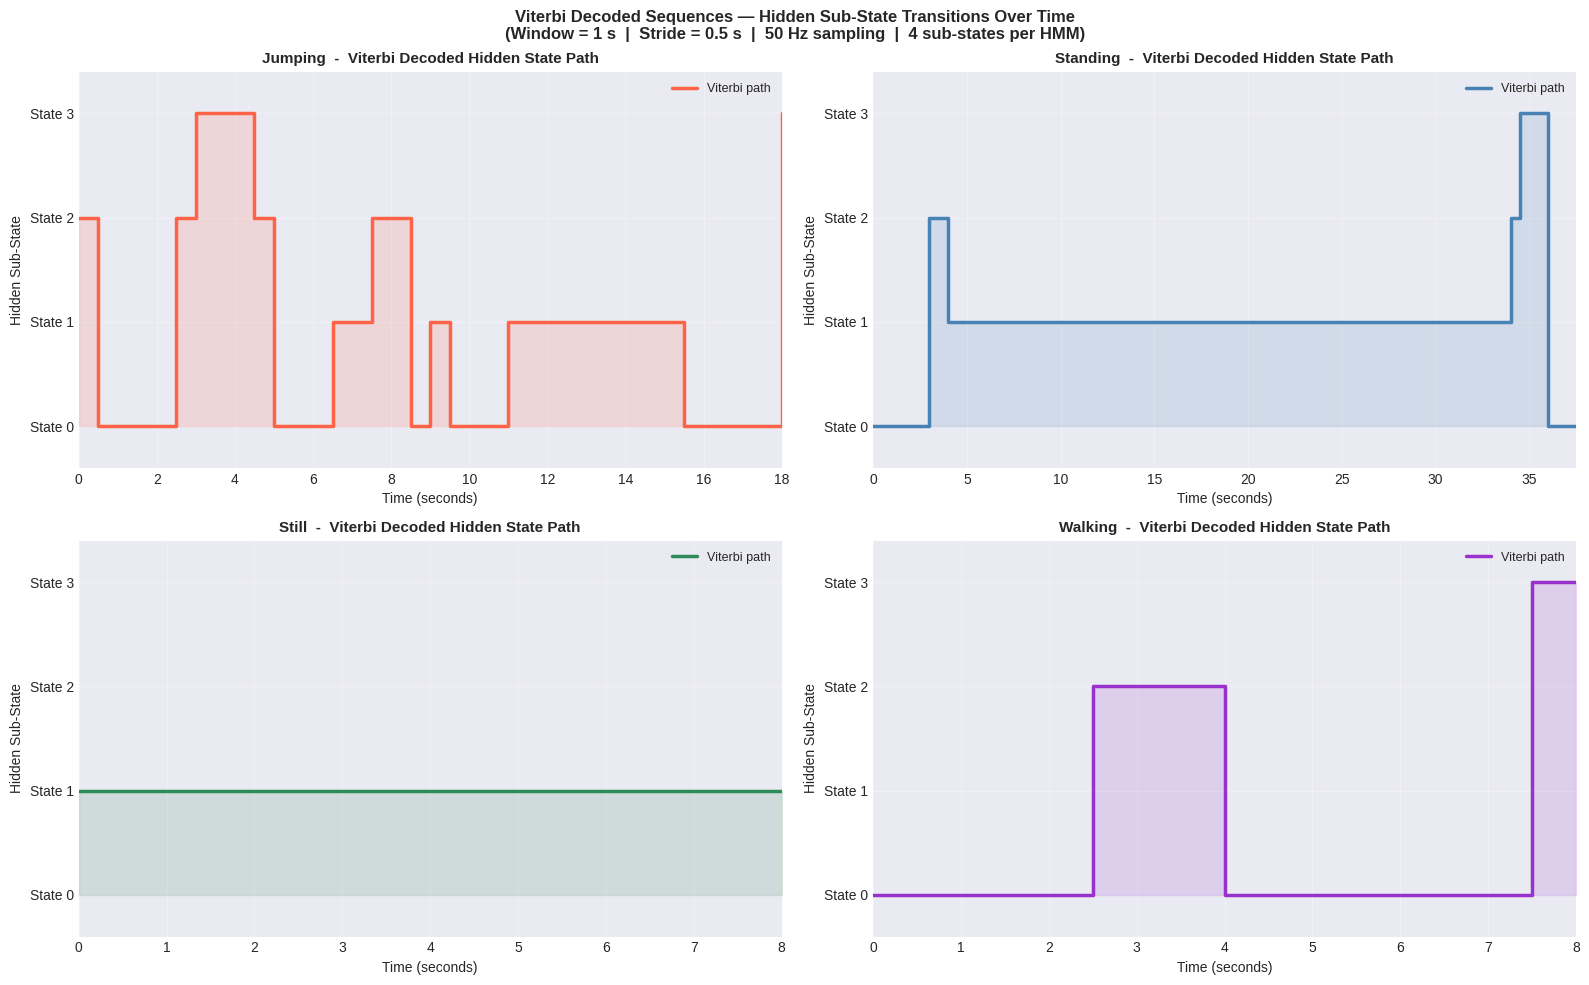

Interpretation:
  - A plateau (flat region) = model stays in one hidden sub-state.
  - A step (vertical jump)  = model detects a phase change within the activity.
  - Jumping typically shows rapid sub-state switching:
    crouch (0) -> push-off (1) -> airborne (2) -> landing (3) -> repeat.
  - Still/Standing show long plateaus — minimal dynamics.
  - Walking shows a regular periodic pattern matching the gait cycle.


In [17]:
# Viterbi Decoded Sequence Visualization
# For each activity, decode the most likely hidden-state path through a
# representative test sequence and plot the temporal state transitions.
# Each window corresponds to 0.5 s of real time (stride = 25 samples at 50 Hz).

colors_act = {
    'Jumping':  'tomato',
    'Standing': 'steelblue',
    'Still':    'seagreen',
    'Walking':  'darkorchid'
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes_flat = axes.flatten()

for i, activity in enumerate(sorted(activity_labels)):
    act_idx = label_to_idx[activity]
    colour  = colors_act.get(activity, 'steelblue')

    # Find the first test sequence for this activity
    for seq, true_label in zip(X_test_sequences, y_test_sequences):
        if true_label == act_idx:
            decoded = hmm_models[act_idx].viterbi(seq)
            T       = len(decoded)
            # Convert window index to real time (each stride = 0.5 s at 50 Hz)
            time_s  = np.arange(T) * 0.5

            ax = axes_flat[i]
            ax.step(time_s, decoded, where='post',
                    color=colour, linewidth=2.5, label='Viterbi path')
            ax.fill_between(time_s, decoded, step='post',
                            alpha=0.15, color=colour)
            ax.set_xlabel('Time (seconds)', fontsize=10)
            ax.set_ylabel('Hidden Sub-State', fontsize=10)
            ax.set_yticks(range(n_states_per_class))
            ax.set_yticklabels([f'State {k}' for k in range(n_states_per_class)])
            ax.set_title(f'{activity}  -  Viterbi Decoded Hidden State Path',
                         fontsize=11, fontweight='bold')
            ax.set_xlim(0, max(time_s))
            ax.set_ylim(-0.4, n_states_per_class - 0.6)
            ax.grid(alpha=0.3)
            ax.legend(fontsize=9)
            break

plt.suptitle(
    'Viterbi Decoded Sequences — Hidden Sub-State Transitions Over Time\n'
    '(Window = 1 s  |  Stride = 0.5 s  |  50 Hz sampling  |  4 sub-states per HMM)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

print("Interpretation:")
print("  - A plateau (flat region) = model stays in one hidden sub-state.")
print("  - A step (vertical jump)  = model detects a phase change within the activity.")
print("  - Jumping typically shows rapid sub-state switching:")
print("    crouch (0) -> push-off (1) -> airborne (2) -> landing (3) -> repeat.")
print("  - Still/Standing show long plateaus — minimal dynamics.")
print("  - Walking shows a regular periodic pattern matching the gait cycle.")


## 9. Feature Importance Analysis


Top 15 Most Discriminative Features (std of class-level mean emissions):
-------------------------------------------------------
   1. accel_magnitude_mean                      1.1092
   2. accel_magnitude_std                       1.1071
   3. accel_sma                                 1.1042
   4. accel_z_rms                               1.0867
   5. accel_z_std                               1.0818
   6. accel_y_range                             1.0678
   7. accel_z_min                               1.0637
   8. accel_y_std                               1.0584
   9. accel_z_range                             1.0549
  10. accel_y_rms                               1.0520
  11. gyro_x_range                              1.0505
  12. gyro_x_rms                                1.0321
  13. gyro_x_std                                1.0296
  14. accel_y_min                               1.0263
  15. gyro_x_max                                1.0240
---------------------------------------------

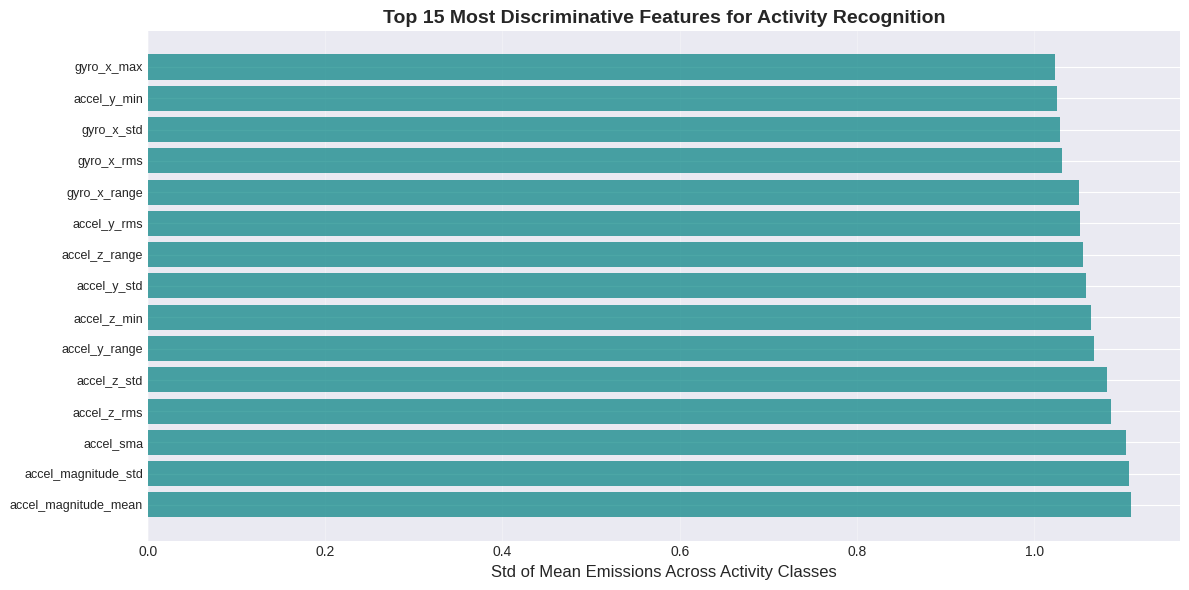

In [18]:
# Feature importance: std of per-activity mean emissions across activities.
# High std → feature differs a lot between activities → discriminative.

# For each activity, compute the average emission mean across hidden states
class_means = np.array([
    hmm_models[label_to_idx[act]].means.mean(axis=0)
    for act in activity_labels
])  # shape: (n_activities, n_features)

mean_diff = np.std(class_means, axis=0)
top_features_idx = np.argsort(mean_diff)[-15:][::-1]

print("\nTop 15 Most Discriminative Features (std of class-level mean emissions):")
print("-" * 55)
for i, idx in enumerate(top_features_idx, 1):
    print(f"  {i:>2}. {feature_column_names[idx]:<40}  {mean_diff[idx]:.4f}")
print("-" * 55)

# Visualise
plt.figure(figsize=(12, 6))
feature_names  = [feature_column_names[i] for i in top_features_idx]
feature_imp    = mean_diff[top_features_idx]

plt.barh(range(len(feature_names)), feature_imp, color='teal', alpha=0.7)
plt.yticks(range(len(feature_names)), feature_names, fontsize=9)
plt.xlabel('Std of Mean Emissions Across Activity Classes', fontsize=12)
plt.title('Top 15 Most Discriminative Features for Activity Recognition',
          fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


## 10. State Emission Distributions

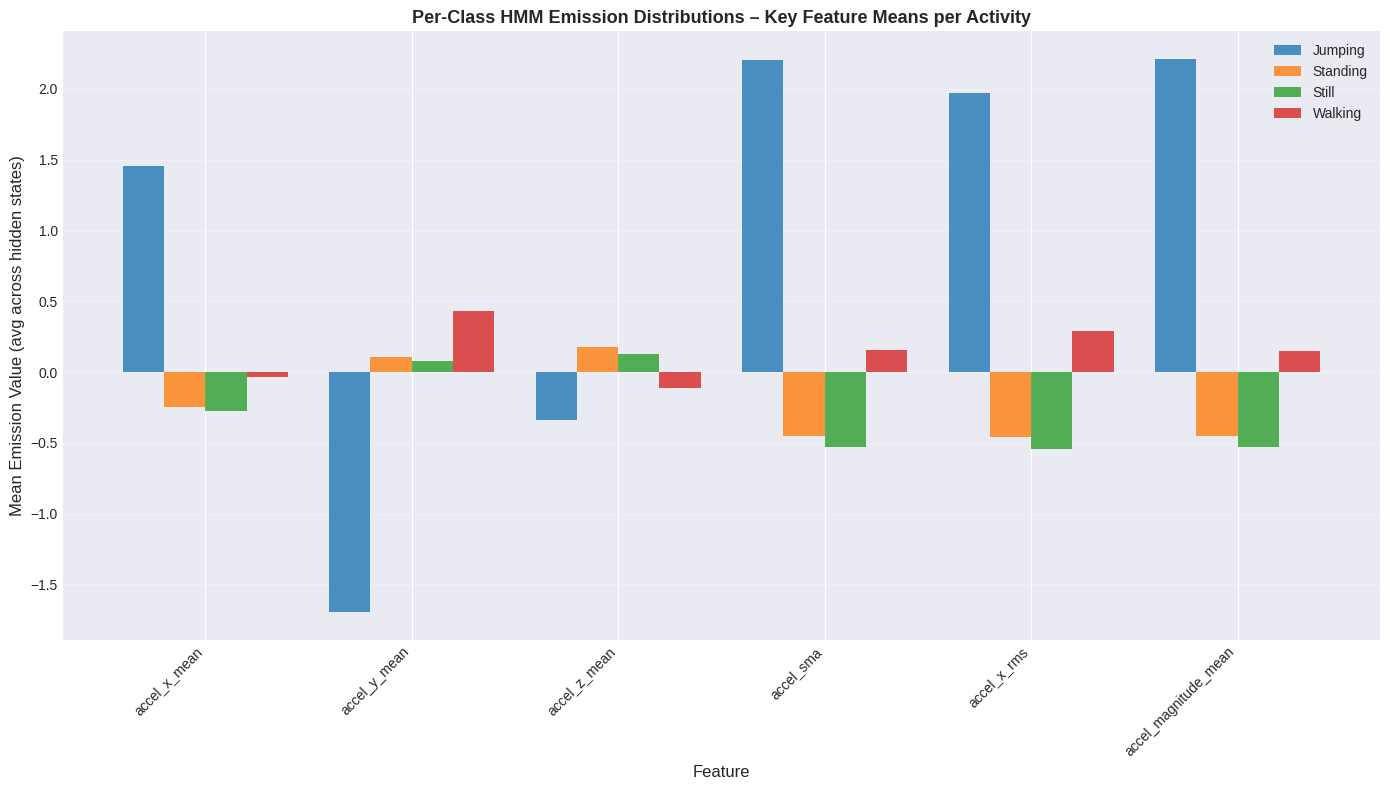

In [19]:
# Visualise emission distributions: average hidden-state mean per activity
key_features = [
    'accel_x_mean', 'accel_y_mean', 'accel_z_mean',
    'accel_sma', 'accel_x_rms', 'accel_magnitude_mean'
]
key_feature_idx = [feature_column_names.index(f) for f in key_features
                   if f in feature_column_names]

if len(key_feature_idx) > 0:
    # Average the emission means across hidden states for each activity HMM
    class_emissions = {
        act: hmm_models[label_to_idx[act]].means.mean(axis=0)[key_feature_idx]
        for act in activity_labels
    }

    plt.figure(figsize=(14, 8))
    x     = np.arange(len(key_feature_idx))
    width = 0.2

    for i, activity in enumerate(activity_labels):
        plt.bar(x + i * width, class_emissions[activity], width,
                label=activity, alpha=0.8)

    plt.xlabel('Feature', fontsize=12)
    plt.ylabel('Mean Emission Value (avg across hidden states)', fontsize=12)
    plt.title('Per-Class HMM Emission Distributions – Key Feature Means per Activity',
              fontsize=13, fontweight='bold')
    feature_tick_names = [feature_column_names[i] for i in key_feature_idx]
    plt.xticks(x + width * 1.5, feature_tick_names, rotation=45, ha='right')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
